
# Data Spaces as Enablers of AI
### A Practical Demo Using Energy Data 

This notebook shows how data spaces help AI by turning separate organisational datasets into a governed, combined, AI-ready dataset.

We use an energy example inspired by real initiatives such as Gaia-X, IDSA, Catena-X, and emerging energy data spaces.



## 1. Getting Data Online

We use the **Open Power System Data (OPSD)** project's German daily time series dataset. It contains electricity consumption, wind generation, and solar generation.



In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/jenfly/opsd/master/opsd_germany_daily.csv"
LOCAL_FILE = "data/opsd_germany_daily.csv"

urllib.request.urlretrieve(DATA_URL, LOCAL_FILE)

raw = pd.read_csv(LOCAL_FILE, parse_dates=["Date"])
print(f"Rows: {len(raw)}, Columns: {list(raw.columns)}")
print(f"Date range: {raw['Date'].min().date()} to {raw['Date'].max().date()}")
raw.head()


Rows: 4383, Columns: ['Date', 'Consumption', 'Wind', 'Solar', 'Wind+Solar']
Date range: 2006-01-01 to 2017-12-31


,Date,Consumption,Wind,Solar,Wind+Solar
0,2006-01-01,1069.184,NaN,NaN,NaN
1,2006-01-02,1380.521,NaN,NaN,NaN
2,2006-01-03,1442.533,NaN,NaN,NaN
3,2006-01-04,1457.217,NaN,NaN,NaN
4,2006-01-05,1477.131,NaN,NaN,NaN


## 2. Simulating independent data providers

To model a data space, we split the dataset into three provider datasets:

| Provider | Data held |
|---|---|
| `GridOperatorDE` | Electricity consumption |
| `WindEnergyCo` | Wind generation |
| `SolarEnergyCo` | Solar generation |

This simulates how real organisations hold different parts of the data needed for AI analysis.


In [ ]:

# Provider 1: Grid Operator - electricity consumption
provider_grid = raw[["Date", "Consumption"]].copy()
provider_grid.columns = ["timestamp", "consumption_gwh"]

# Provider 2: Wind Energy Co - wind generation 
provider_wind = raw[["Date", "Wind"]].dropna().copy()
provider_wind.columns = ["date_recorded", "wind_gen_GWh"]

# Provider 3: Solar Energy Co - solar generation 
provider_solar = raw[["Date", "Solar"]].dropna().copy()
provider_solar["Solar"] = provider_solar["Solar"] * 1000  # GWh -> MWh
provider_solar.columns = ["recorded_on", "solar_generation_mwh"]

print("GridOperatorDE  :", provider_grid.shape, "| columns:", list(provider_grid.columns))
print("WindEnergyCo    :", provider_wind.shape, "| columns:", list(provider_wind.columns))
print("SolarEnergyCo   :", provider_solar.shape, "| columns:", list(provider_solar.columns))

provider_grid.to_csv("provider_grid_operator.csv", index=False)
provider_wind.to_csv("provider_wind_energy.csv", index=False)
provider_solar.to_csv("provider_solar_energy.csv", index=False)


GridOperatorDE  : (4383, 2) | columns: ['timestamp', 'consumption_gwh']
WindEnergyCo    : (2920, 2) | columns: ['date_recorded', 'wind_gen_GWh']
SolarEnergyCo   : (2188, 2) | columns: ['recorded_on', 'solar_generation_mwh']



## 3. Data Space Layer: Connectors and Usage Policies

A data space is not just file sharing. Data remains with the owner, and access is controlled by policies.

Here, we simulate a connector that checks whether a request is allowed before releasing data. This represents the role of tools such as IDS Connectors or Eclipse Dataspace Components.


In [3]:

from dataclasses import dataclass, field
from datetime import datetime

@dataclass
class UsagePolicy:
    # Mirrors a simplified ODRL-style usage policy, as used in Gaia-X / IDSA contracts.
    owner: str
    allowed_purposes: list
    requires_aggregation: bool = False

@dataclass
class DataAsset:
    name: str
    dataframe: object
    policy: UsagePolicy

@dataclass
class AccessRequest:
    requester: str
    asset_name: str
    purpose: str

class DataSpaceConnector:
    # A toy connector: registers data assets + policies, and arbitrates access requests.

    def __init__(self):
        self.catalog = {}

    def register(self, asset: DataAsset):
        self.catalog[asset.name] = asset
        print(f"[Catalog] Registered '{asset.name}' (owner: {asset.policy.owner}), "
              f"allowed purposes: {asset.policy.allowed_purposes}")

    def request_access(self, request: AccessRequest):
        asset = self.catalog.get(request.asset_name)
        if asset is None:
            print(f"[DENIED] Asset '{request.asset_name}' not found in catalog.")
            return None

        if request.purpose not in asset.policy.allowed_purposes:
            print(f"[DENIED] {request.requester} requested '{request.asset_name}' "
                  f"for '{request.purpose}' - not in allowed purposes "
                  f"{asset.policy.allowed_purposes}")
            return None

        print(f"[GRANTED] {request.requester} -> '{request.asset_name}' "
              f"for purpose '{request.purpose}' (owner: {asset.policy.owner})")
        df = asset.dataframe.copy()

        if asset.policy.requires_aggregation:
            print(f"  -> Policy requires aggregation: returning monthly aggregates only.")
            df = df.set_index(df.columns[0])
            df = df.resample("MS").mean().reset_index()

        return df

connector = DataSpaceConnector()

connector.register(DataAsset(
    name="grid_consumption",
    dataframe=provider_grid,
    policy=UsagePolicy(owner="GridOperatorDE",
                        allowed_purposes=["AI forecasting research", "grid planning"],
                        requires_aggregation=False)
))

connector.register(DataAsset(
    name="wind_generation",
    dataframe=provider_wind,
    policy=UsagePolicy(owner="WindEnergyCo",
                        allowed_purposes=["AI forecasting research"],
                        requires_aggregation=False)
))

connector.register(DataAsset(
    name="solar_generation",
    dataframe=provider_solar,
    policy=UsagePolicy(owner="SolarEnergyCo",
                        allowed_purposes=["AI forecasting research"],
                        requires_aggregation=True)  # solar provider only shares monthly aggregates
))


[Catalog] Registered 'grid_consumption' (owner: GridOperatorDE), allowed purposes: ['AI forecasting research', 'grid planning']
[Catalog] Registered 'wind_generation' (owner: WindEnergyCo), allowed purposes: ['AI forecasting research']
[Catalog] Registered 'solar_generation' (owner: SolarEnergyCo), allowed purposes: ['AI forecasting research']



### Demonstrating policy enforcement

An **AI research team** (`RenewableForecastAI`) requests access to all three datasets
for the purpose of *"AI forecasting research"*. We also show what happens when a
request is made for a **disallowed purpose** (e.g. *"commercial resale"*), the
connector denies it, exactly as a real Gaia-X/IDS connector would.


In [4]:

# Allowed: AI forecasting research
df_grid  = connector.request_access(AccessRequest("RenewableForecastAI", "grid_consumption", "AI forecasting research"))
df_wind  = connector.request_access(AccessRequest("RenewableForecastAI", "wind_generation", "AI forecasting research"))
df_solar = connector.request_access(AccessRequest("RenewableForecastAI", "solar_generation", "AI forecasting research"))

print()
# Disallowed: commercial resale (policy violation)
_ = connector.request_access(AccessRequest("AdTechCorp", "wind_generation", "commercial resale"))


[GRANTED] RenewableForecastAI -> 'grid_consumption' for purpose 'AI forecasting research' (owner: GridOperatorDE)
[GRANTED] RenewableForecastAI -> 'wind_generation' for purpose 'AI forecasting research' (owner: WindEnergyCo)
[GRANTED] RenewableForecastAI -> 'solar_generation' for purpose 'AI forecasting research' (owner: SolarEnergyCo)
  -> Policy requires aggregation: returning monthly aggregates only.

[DENIED] AdTechCorp requested 'wind_generation' for 'commercial resale' - not in allowed purposes ['AI forecasting research']


In [5]:

print("\nReturned to RenewableForecastAI:")
print("grid_consumption  ->", df_grid.shape)
print("wind_generation   ->", df_wind.shape)
print("solar_generation  -> (aggregated to monthly, per SolarEnergyCo policy)", df_solar.shape)
df_solar.head()



Returned to RenewableForecastAI:
grid_consumption  -> (4383, 2)
wind_generation   -> (2920, 2)
solar_generation  -> (aggregated to monthly, per SolarEnergyCo policy) (72, 2)


,recorded_on,solar_generation_mwh
0,2012-01-01,17346.451613
1,2012-02-01,36093.724138
2,2012-03-01,75706.354839
3,2012-04-01,89109.933333
4,2012-05-01,133747.741935


## 4. Preprocessing and harmonisation

The three providers use different column names, units, and time coverage. Before AI analysis, the data must be harmonised.

Main steps:
1. Rename columns.
2. Convert units.
3. Align dates.
4. Handle missing values.


In [6]:

# 1. Standardise column names and date columns
df_grid = df_grid.rename(columns={"timestamp": "date", "consumption_gwh": "consumption_gwh"})
df_wind = df_wind.rename(columns={"date_recorded": "date", "wind_gen_GWh": "wind_gwh"})

df_solar = df_solar.rename(columns={"recorded_on": "date", "solar_generation_mwh": "solar_mwh"})
df_solar["solar_gwh"] = df_solar["solar_mwh"] / 1000  # MWh -> GWh, harmonising units
df_solar = df_solar.drop(columns=["solar_mwh"])

for d in (df_grid, df_wind, df_solar):
    d["date"] = pd.to_datetime(d["date"])

# 2. Solar arrived as monthly aggregates -> upsample to daily via forward-fill
#    (clearly flagged, since this is an approximation introduced by the policy)
df_solar = df_solar.set_index("date").resample("D").ffill().reset_index()

print("After harmonisation:")
print("grid  :", df_grid.shape, list(df_grid.columns))
print("wind  :", df_wind.shape, list(df_wind.columns))
print("solar :", df_solar.shape, list(df_solar.columns))


After harmonisation:
grid  : (4383, 2) ['date', 'consumption_gwh']
wind  : (2920, 2) ['date', 'wind_gwh']
solar : (2162, 2) ['date', 'solar_gwh']


In [7]:

# 3. Align all three datasets on a common date range (inner join)
combined = df_grid.merge(df_wind, on="date", how="inner").merge(df_solar, on="date", how="inner")

print(f"Combined dataset (data-space view): {combined.shape}")
print(f"Date range: {combined['date'].min().date()} to {combined['date'].max().date()}")

# 4. Check for remaining missing values
print("\nMissing values:\n", combined.isna().sum())

combined = combined.dropna().reset_index(drop=True)
combined["renewable_gwh"] = combined["wind_gwh"] + combined["solar_gwh"]
combined["renewable_share_pct"] = (combined["renewable_gwh"] / combined["consumption_gwh"]) * 100

combined.head()


Combined dataset (data-space view): (2161, 4)
Date range: 2012-01-01 to 2017-12-01

Missing values:
 date               0
consumption_gwh    0
wind_gwh           0
solar_gwh          0
dtype: int64


,date,consumption_gwh,wind_gwh,solar_gwh,renewable_gwh,renewable_share_pct
0,2012-01-01,948.128,227.465,17.346452,244.811452,25.820506
1,2012-01-02,1269.581,207.327,17.346452,224.673452,17.696661
2,2012-01-03,1334.745,473.468,17.346452,490.814452,36.772151
3,2012-01-04,1347.136,499.804,17.346452,517.150452,38.388882
4,2012-01-05,1376.658,523.851,17.346452,541.197452,39.312411



## 5. Visualisation: siloed view vs combined view

### 5.1 Siloed provider view

This shows what each organisation can see before sharing data through a data space.


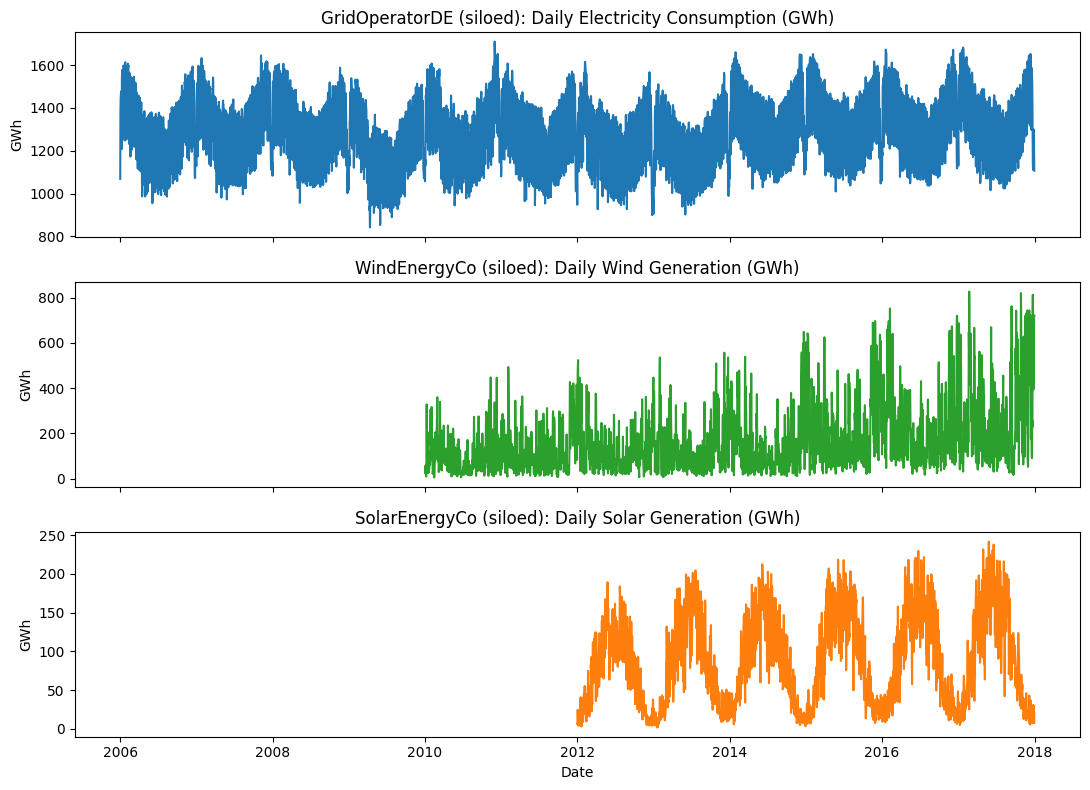

In [8]:

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(provider_grid["timestamp"], provider_grid["consumption_gwh"], color="#1f77b4")
axes[0].set_title("GridOperatorDE (siloed): Daily Electricity Consumption (GWh)")
axes[0].set_ylabel("GWh")

axes[1].plot(provider_wind["date_recorded"], provider_wind["wind_gen_GWh"], color="#2ca02c")
axes[1].set_title("WindEnergyCo (siloed): Daily Wind Generation (GWh)")
axes[1].set_ylabel("GWh")

axes[2].plot(provider_solar["recorded_on"], provider_solar["solar_generation_mwh"] / 1000, color="#ff7f0e")
axes[2].set_title("SolarEnergyCo (siloed): Daily Solar Generation (GWh)")
axes[2].set_ylabel("GWh")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.savefig("siloed_view.png", dpi=120)
plt.show()


### 5.2 Combined data-space view

After access is granted and the data is harmonised, we can compare electricity consumption with renewable generation. This creates an AI-ready dataset for forecasting and grid analytics.


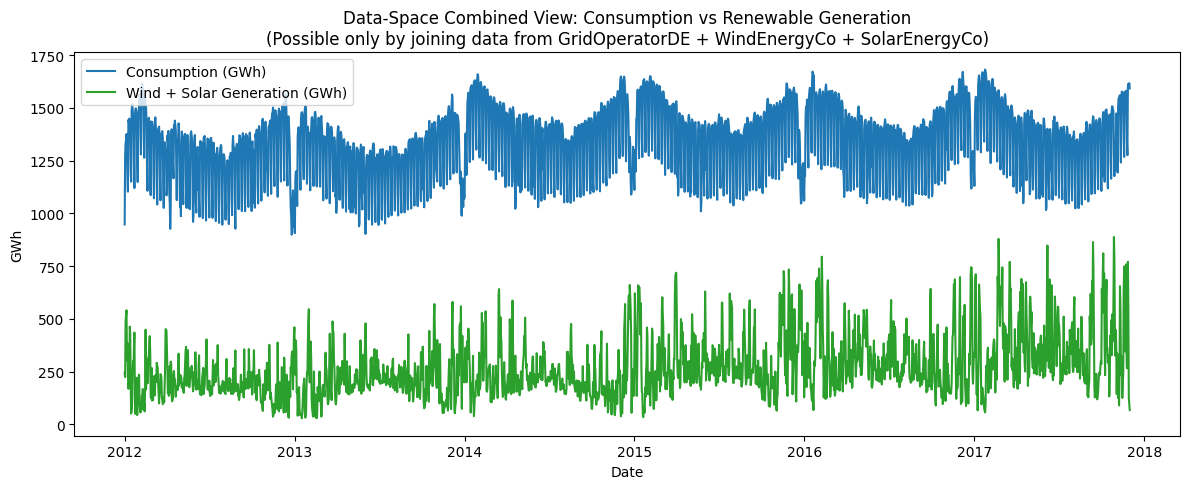

In [9]:

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(combined["date"], combined["consumption_gwh"], color="#1f77b4", label="Consumption (GWh)")
ax1.plot(combined["date"], combined["renewable_gwh"], color="#2ca02c", label="Wind + Solar Generation (GWh)")
ax1.set_ylabel("GWh")
ax1.set_xlabel("Date")
ax1.set_title("Data-Space Combined View: Consumption vs Renewable Generation\n"
               "(Possible only by joining data from GridOperatorDE + WindEnergyCo + SolarEnergyCo)")
ax1.legend(loc="upper left")

plt.tight_layout()
plt.savefig("combined_view.png", dpi=120)
plt.show()


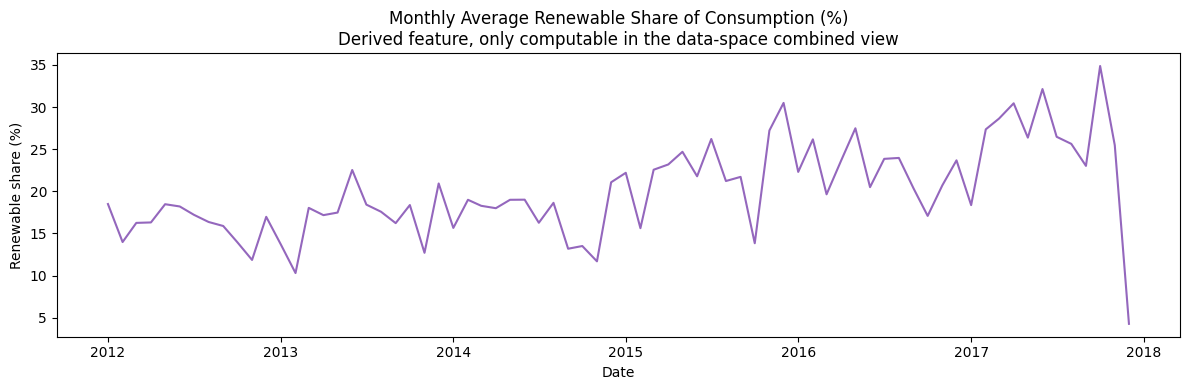

Average renewable share over the period: 20.29%
Max single-day renewable share: 69.19% on 2017-10-28


In [10]:

# Renewable share of consumption over time - a typical AI/analytics-ready feature
fig, ax = plt.subplots(figsize=(12, 4))

monthly = combined.set_index("date")["renewable_share_pct"].resample("MS").mean()
ax.plot(monthly.index, monthly.values, color="#9467bd")
ax.set_title("Monthly Average Renewable Share of Consumption (%)\n"
              "Derived feature, only computable in the data-space combined view")
ax.set_ylabel("Renewable share (%)")
ax.set_xlabel("Date")

plt.tight_layout()
plt.savefig("renewable_share.png", dpi=120)
plt.show()

print(f"Average renewable share over the period: {combined['renewable_share_pct'].mean():.2f}%")
print(f"Max single-day renewable share: {combined['renewable_share_pct'].max():.2f}% "
      f"on {combined.loc[combined['renewable_share_pct'].idxmax(), 'date'].date()}")


### 5.3 AI-readiness check

The correlation matrix helps us see relationships between consumption, wind, solar, and renewable share. These relationships can support forecasting or prediction models.



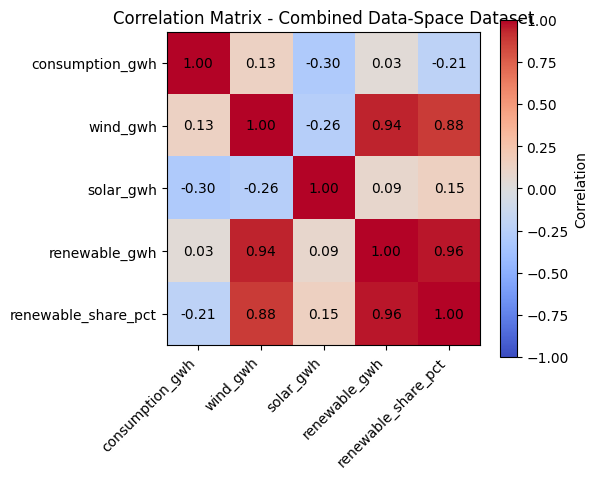

In [11]:

import matplotlib.pyplot as plt

corr = combined[["consumption_gwh", "wind_gwh", "solar_gwh", "renewable_gwh", "renewable_share_pct"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_title("Correlation Matrix - Combined Data-Space Dataset")
fig.colorbar(im, label="Correlation")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=120)
plt.show()


## 6. Real-world adoption and market-ready solutions

This demo reflects what real data spaces do at scale. Examples include:

- **Catena-X**: automotive data space for supply chain, traceability, CO₂/Product Carbon Footprint data, and AI-enabled analytics.
- **Cofinity-X**: market-ready marketplace for Catena-X applications and services.
- **Gaia-X / IDSA**: frameworks for trusted, sovereign, and policy-based data sharing.
- **Energy data spaces**: support renewable forecasting, grid balancing, and demand-response AI.

These examples show that data spaces are practical infrastructures for AI, not just theoretical concepts.


## Conclusion

This notebook analyzed selected data space initiatives to show how they support practical AI adoption. The dataset was created from publicly available secondary data on real-world initiatives such as Catena-X, Cofinity-X, Mobility Data Space, European Common Data Spaces, and European Health Data Space.

The results show that data spaces are already being used as practical and market-ready solutions in sectors such as automotive, mobility, healthcare, and multi-sector European data ecosystems. They enable AI by improving access to trusted data, reducing data silos, supporting data sovereignty, and creating the conditions for secure data sharing.

The visualizations also show that data spaces support AI use cases such as supply chain optimization, predictive maintenance, carbon tracking, quality analytics, traffic prediction, route optimization, healthcare AI, and energy optimization. Overall, data spaces are important enablers of AI because they provide the trusted and governed data-sharing foundation needed for real-world AI solutions.